In [46]:
# import pandas as pd
# Extract raw txt data to one
# # 读取Excel文件
# file_path = 'your_excel_file.xlsx'  # 替换为您的文件路径
# df = pd.read_excel(file_path)

# # 逐个单元格处理，提取最后一个数值
# def extract_last_number(cell):
#     # 使用逗号分隔并获取最后一个元素
#     try:
#         return float(cell.split(',')[-1].strip())
#     except:
#         return cell  # 若非数字，保留原始值

# # 对整个DataFrame进行处理
# df = df.applymap(lambda x: extract_last_number(str(x)))

# # 将修改后的数据保存到新Excel文件
# output_path = 'modified_excel_file.xlsx'  # 替换为您希望保存的文件路径
# df.to_excel(output_path, index=False)

# print("处理完成并已保存到新文件。")


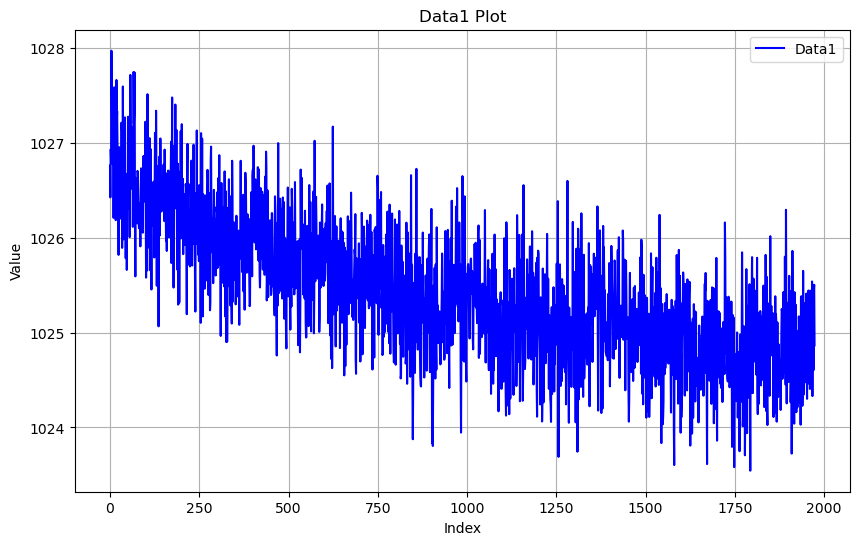

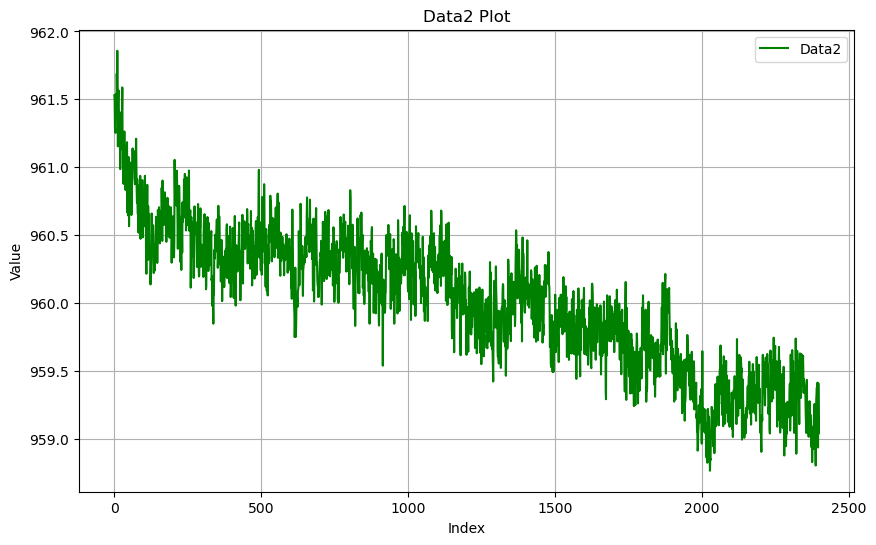

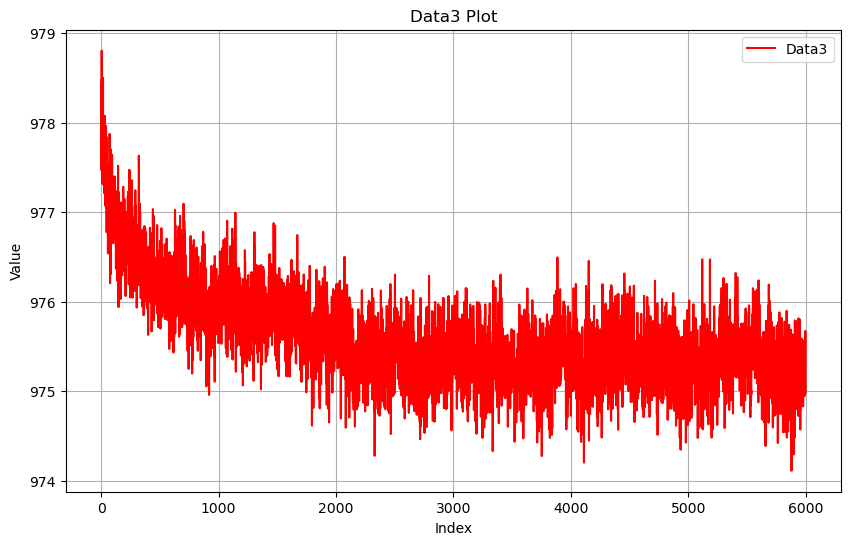

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Load excel file
datapath = 'Activation_trend.xlsx'
data = pd.read_excel(datapath)

# Plot acceleration 100hz, 20s
plt.figure(figsize=(10, 6))
plt.plot(data['Data1'], label='Data1', color='blue')
plt.title('Data1 Plot')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# plot acceleration 20hz, 120s
plt.figure(figsize=(10, 6))
plt.plot(data['Data2'], label='Data2', color='green')
plt.title('Data2 Plot')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# plot acceleration 100hz, 60s
plt.figure(figsize=(10, 6))
plt.plot(data['Data3'], label='Data3', color='red')
plt.title('Data3 Plot')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


In [70]:
import pandas as pd
import numpy as np

# 读取 Excel 数据
datapath = 'Activation_trend.xlsx'
data = pd.read_excel(datapath)

# 定义逐渐变大的系数
n_points = 2000  # num of points
scale_factors = np.linspace(0.999, 1, n_points)  # 从0.999变化到1的系数

# 定义乘以系数的函数
def apply_scaling(column):
    # 前2000个点按系数变化，之后的点系数保持为1
    scaled_values = column.copy()  # 复制原始列数据
    scaled_values[:n_points] *= scale_factors  # 前2000个点乘以scale_factors
    scaled_values[n_points:] *= 1  # 之后的点乘以1（保持不变）
    return scaled_values

# 对Data1, Data2, Data3应用系数变化
data['Data1_scaled'] = apply_scaling(data['Data1'])
data['Data2_scaled'] = apply_scaling(data['Data2'])
data['Data3_scaled'] = apply_scaling(data['Data3'])




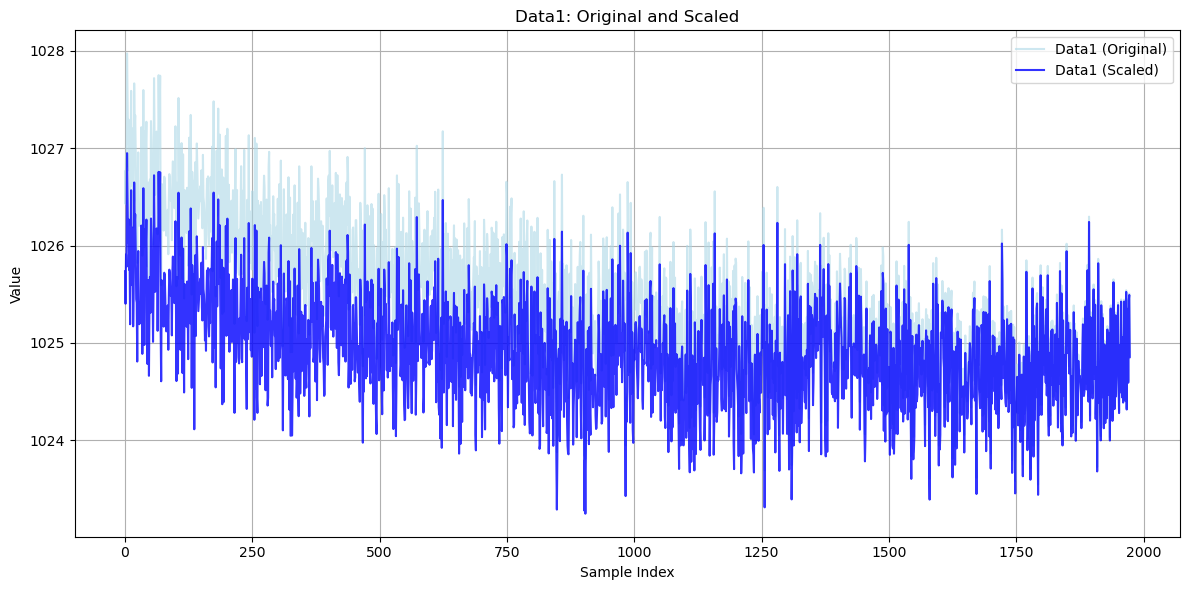

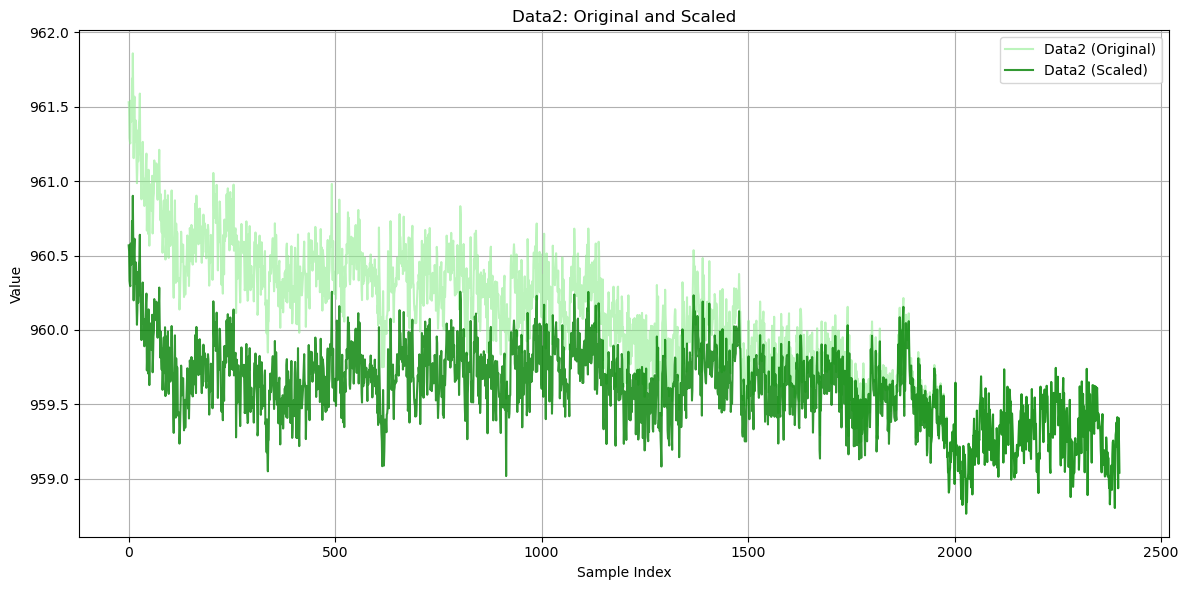

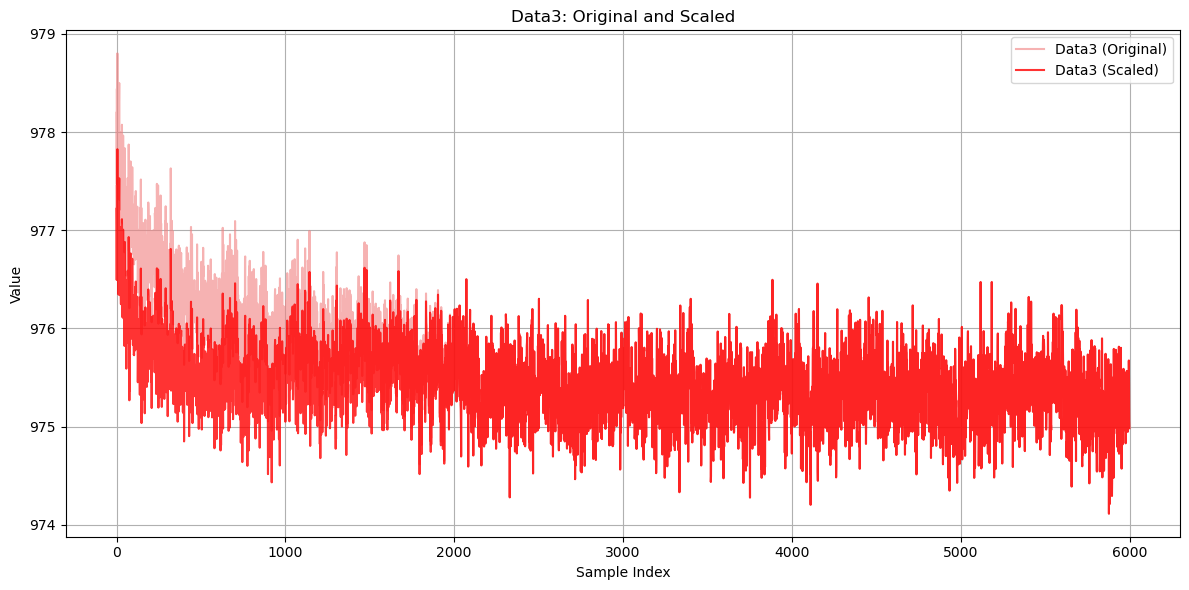

In [74]:
# 绘制Data1
plt.figure(figsize=(12, 6))
plt.plot(data['Data1'], label='Data1 (Original)', color='lightblue', alpha=0.6)
plt.plot(data['Data1_scaled'], label='Data1 (Scaled)', color='blue', alpha=0.8)
plt.title('Data1: Original and Scaled')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.tight_layout()
# plt.savefig('Data1_scaling_plot.png')  # 保存图形
plt.show()

# 绘制Data2
plt.figure(figsize=(12, 6))
plt.plot(data['Data2'], label='Data2 (Original)', color='lightgreen', alpha=0.6)
plt.plot(data['Data2_scaled'], label='Data2 (Scaled)', color='green', alpha=0.8)
plt.title('Data2: Original and Scaled')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.tight_layout()
# plt.savefig('Data2_scaling_plot.png')  # 保存图形
plt.show()

# 绘制Data3
plt.figure(figsize=(12, 6))
plt.plot(data['Data3'], label='Data3 (Original)', color='lightcoral', alpha=0.6)
plt.plot(data['Data3_scaled'], label='Data3 (Scaled)', color='red', alpha=0.8)
plt.title('Data3: Original and Scaled')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.tight_layout()
# plt.savefig('Data3_scaling_plot.png')  # 保存图形
plt.show()

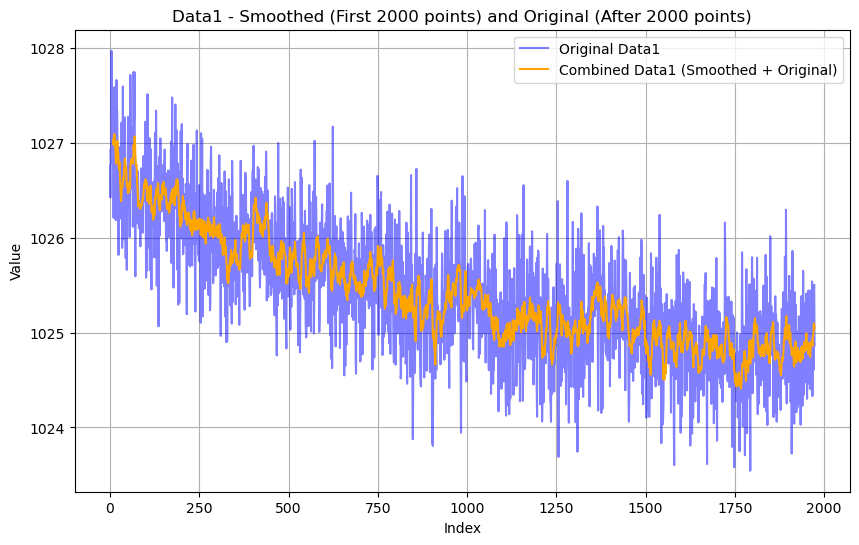

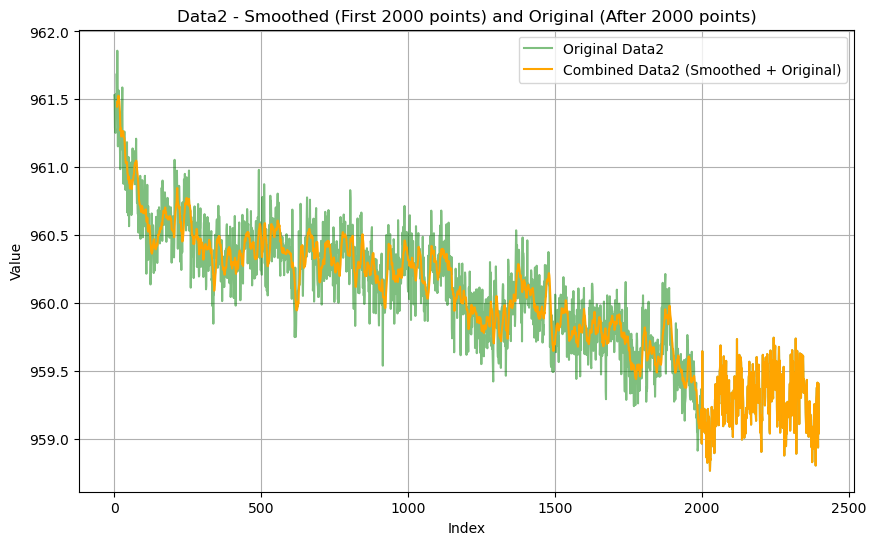

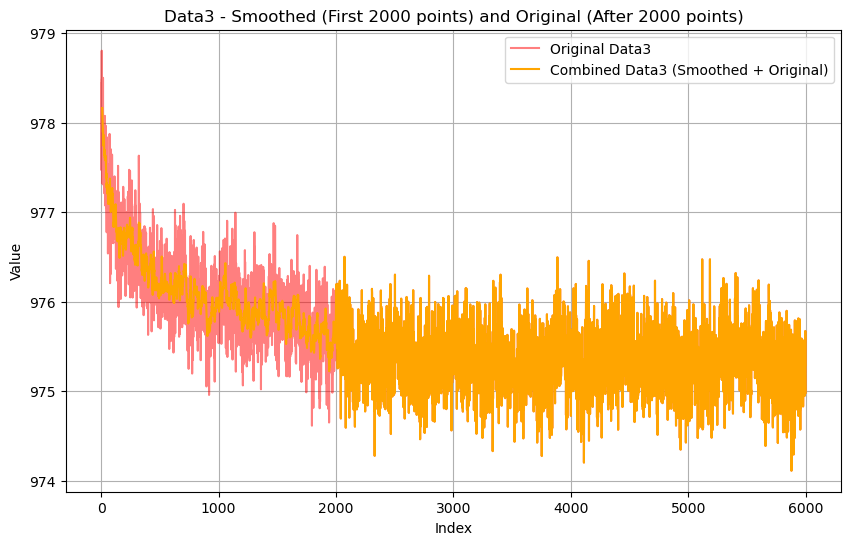

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Load excel file
datapath = 'Activation_trend.xlsx'
data = pd.read_excel(datapath)

# Define window sizes for each dataset (you can adjust these as needed)
window_size_data1 = 10  # e.g., for Data1 (100Hz, 20s)
window_size_data2 = 10   # e.g., for Data2 (20Hz, 120s)
window_size_data3 = 10  # e.g., for Data3 (100Hz, 60s)

# Process the first 2000 data points for each dataset and apply smoothing
data1_smoothed = data['Data1'][:2000].rolling(window=window_size_data1).mean()
data2_smoothed = data['Data2'][:2000].rolling(window=window_size_data2).mean()
data3_smoothed = data['Data3'][:2000].rolling(window=window_size_data3).mean()

# Combine smoothed data (first 2000 points) with original data from point 2000 onward
data1_combined = pd.concat([data1_smoothed, data['Data1'][2000:]])
data2_combined = pd.concat([data2_smoothed, data['Data2'][2000:]])
data3_combined = pd.concat([data3_smoothed, data['Data3'][2000:]])

# Plot Data1: smoothed first 2000 points and raw data after 2000
plt.figure(figsize=(10, 6))
plt.plot(data['Data1'], label='Original Data1', color='blue', alpha=0.5)
plt.plot(data1_combined, label=f'Combined Data1 (Smoothed + Original)', color='orange')
plt.title('Data1 - Smoothed (First 2000 points) and Original (After 2000 points)')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Plot Data2: smoothed first 2000 points and raw data after 2000
plt.figure(figsize=(10, 6))
plt.plot(data['Data2'], label='Original Data2', color='green', alpha=0.5)
plt.plot(data2_combined, label=f'Combined Data2 (Smoothed + Original)', color='orange')
plt.title('Data2 - Smoothed (First 2000 points) and Original (After 2000 points)')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Plot Data3: smoothed first 2000 points and raw data after 2000
plt.figure(figsize=(10, 6))
plt.plot(data['Data3'], label='Original Data3', color='red', alpha=0.5)
plt.plot(data3_combined, label=f'Combined Data3 (Smoothed + Original)', color='orange')
plt.title('Data3 - Smoothed (First 2000 points) and Original (After 2000 points)')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


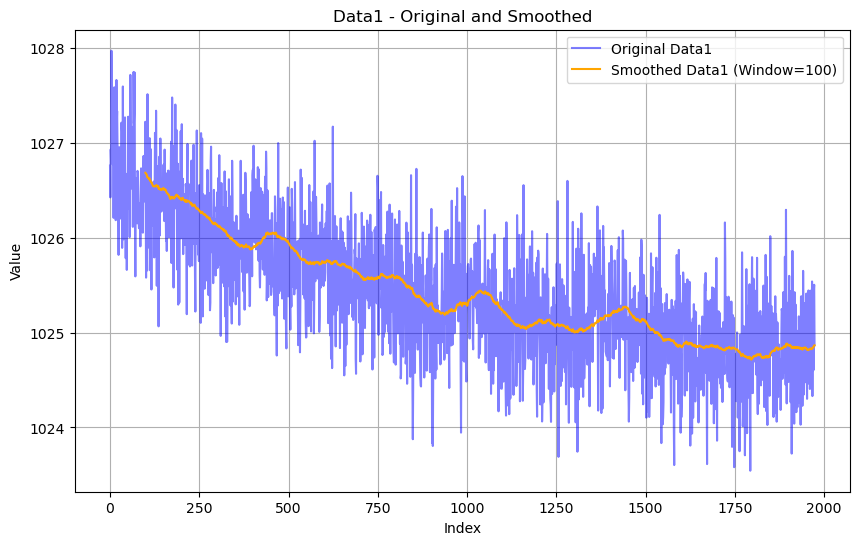

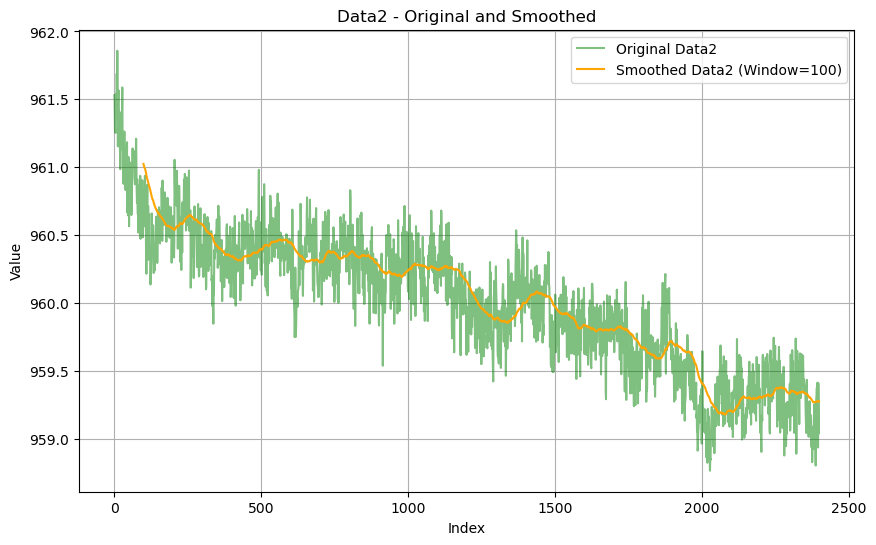

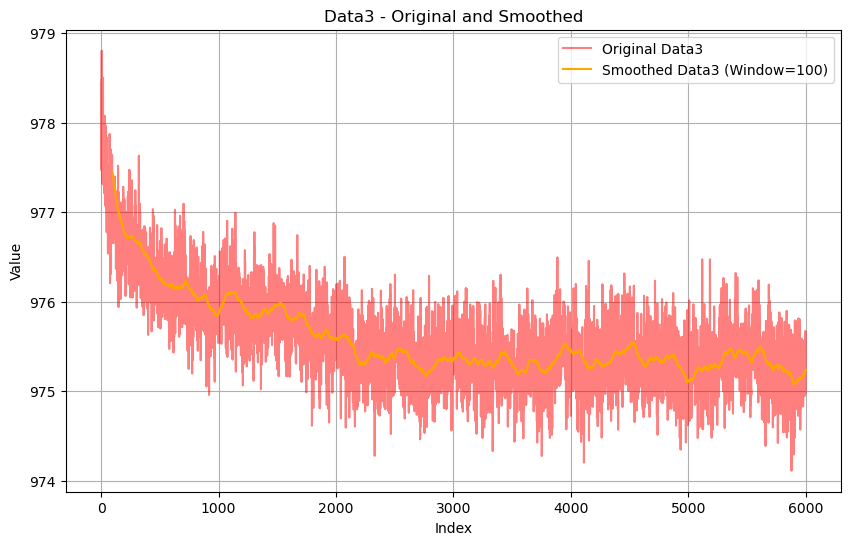

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# Load excel file
datapath = 'Activation_trend.xlsx'
data = pd.read_excel(datapath)

# Define window sizes for each dataset (you can adjust these as needed)
window_size_data1 = 100  # e.g., for Data1 (100Hz, 20s)
window_size_data2 = 100   # e.g., for Data2 (20Hz, 120s)
window_size_data3 = 100  # e.g., for Data3 (100Hz, 60s)

# Apply moving average (sliding window) filter to each dataset
data1_smoothed = data['Data1'].rolling(window=window_size_data1).mean()
data2_smoothed = data['Data2'].rolling(window=window_size_data2).mean()
data3_smoothed = data['Data3'].rolling(window=window_size_data3).mean()

# Plot Data1 with sliding window mean
plt.figure(figsize=(10, 6))
plt.plot(data['Data1'], label='Original Data1', color='blue', alpha=0.5)
plt.plot(data1_smoothed, label=f'Smoothed Data1 (Window={window_size_data1})', color='orange')
plt.title('Data1 - Original and Smoothed')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Plot Data2 with sliding window mean
plt.figure(figsize=(10, 6))
plt.plot(data['Data2'], label='Original Data2', color='green', alpha=0.5)
plt.plot(data2_smoothed, label=f'Smoothed Data2 (Window={window_size_data2})', color='orange')
plt.title('Data2 - Original and Smoothed')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Plot Data3 with sliding window mean
plt.figure(figsize=(10, 6))
plt.plot(data['Data3'], label='Original Data3', color='red', alpha=0.5)
plt.plot(data3_smoothed, label=f'Smoothed Data3 (Window={window_size_data3})', color='orange')
plt.title('Data3 - Original and Smoothed')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()


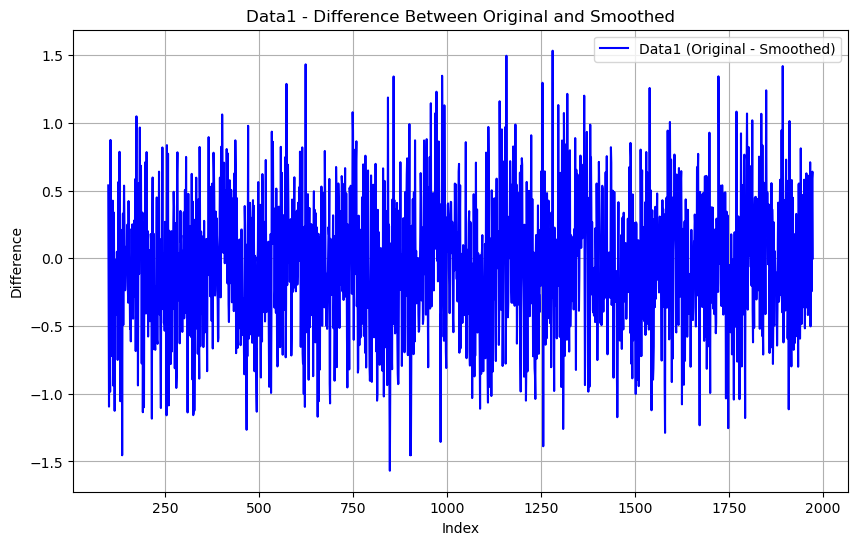

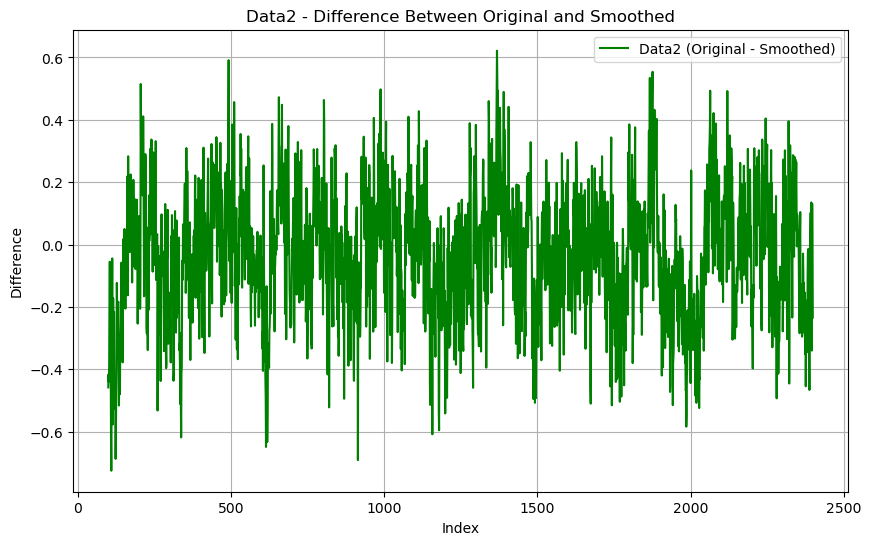

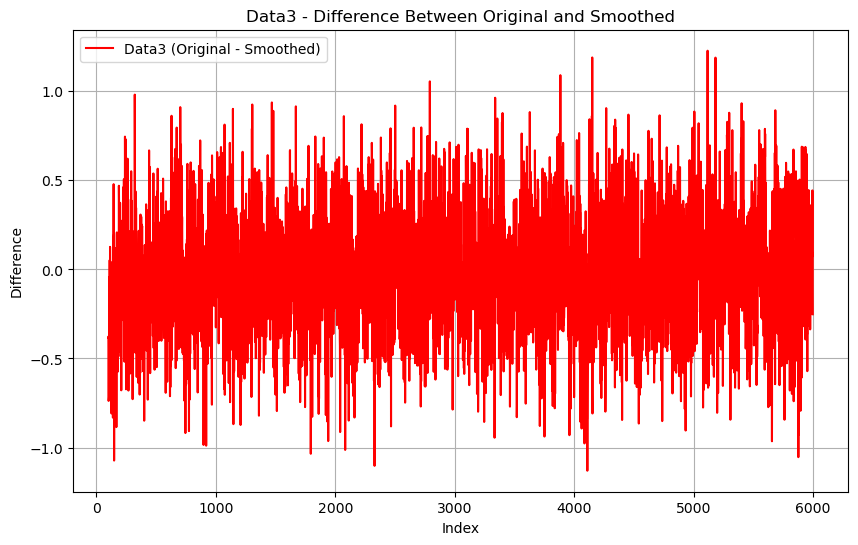

In [54]:
# Calculate the difference between original and smoothed data
data1_diff = data['Data1'] - data1_smoothed
data2_diff = data['Data2'] - data2_smoothed
data3_diff = data['Data3'] - data3_smoothed

# Plot Data1 - Difference between original and smoothed data
plt.figure(figsize=(10, 6))
plt.plot(data1_diff, label='Data1 (Original - Smoothed)', color='blue')
plt.title('Data1 - Difference Between Original and Smoothed')
plt.xlabel('Index')
plt.ylabel('Difference')
plt.legend()
plt.grid(True)
plt.show()

# Plot Data2 - Difference between original and smoothed data
plt.figure(figsize=(10, 6))
plt.plot(data2_diff, label='Data2 (Original - Smoothed)', color='green')
plt.title('Data2 - Difference Between Original and Smoothed')
plt.xlabel('Index')
plt.ylabel('Difference')
plt.legend()
plt.grid(True)
plt.show()

# Plot Data3 - Difference between original and smoothed data
plt.figure(figsize=(10, 6))
plt.plot(data3_diff, label='Data3 (Original - Smoothed)', color='red')
plt.title('Data3 - Difference Between Original and Smoothed')
plt.xlabel('Index')
plt.ylabel('Difference')
plt.legend()
plt.grid(True)
plt.show()

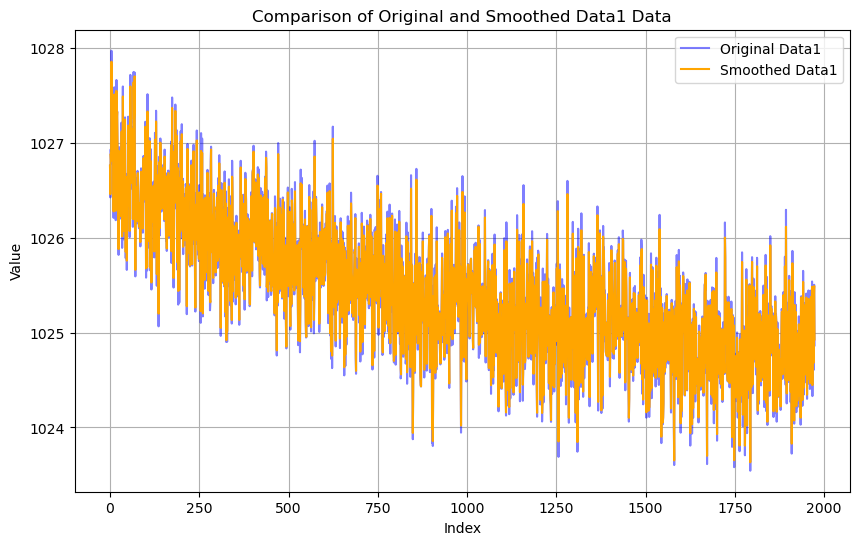

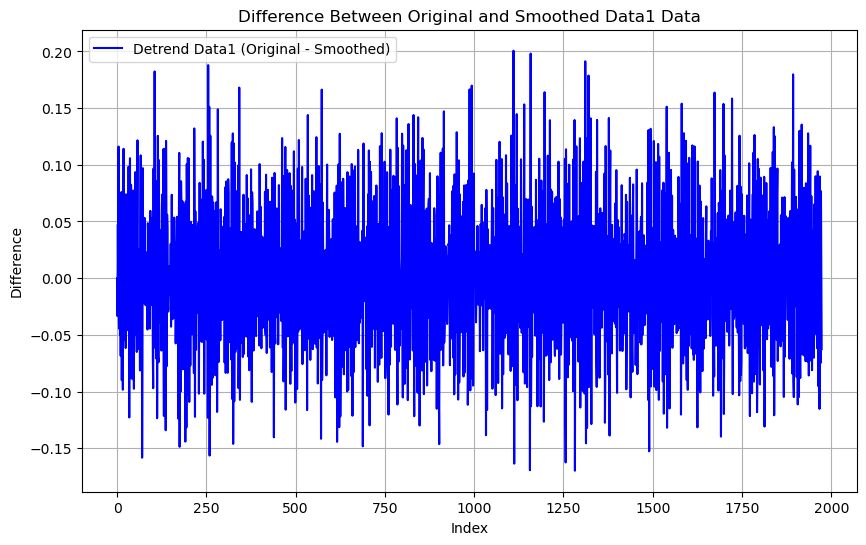

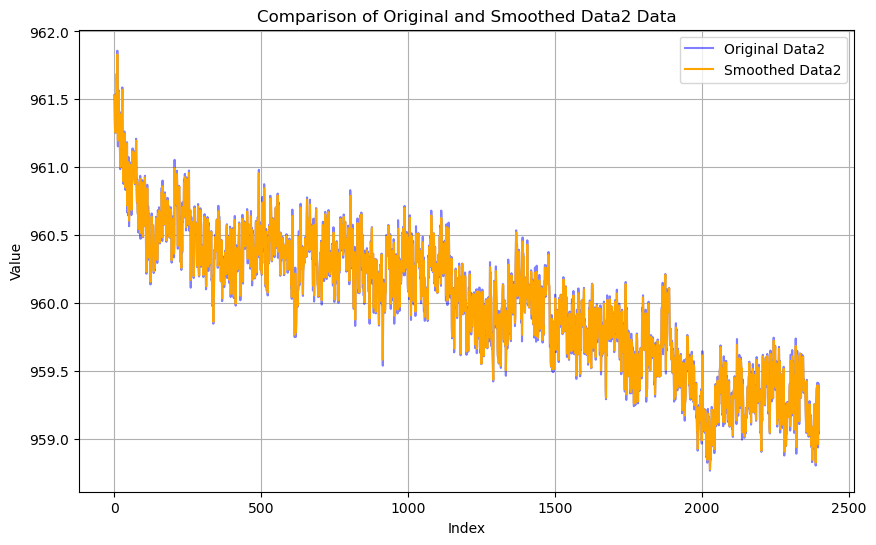

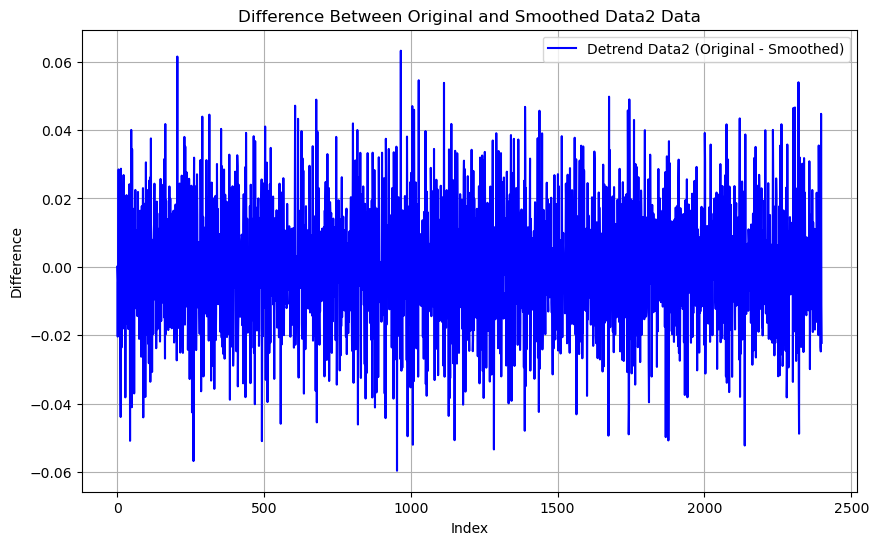

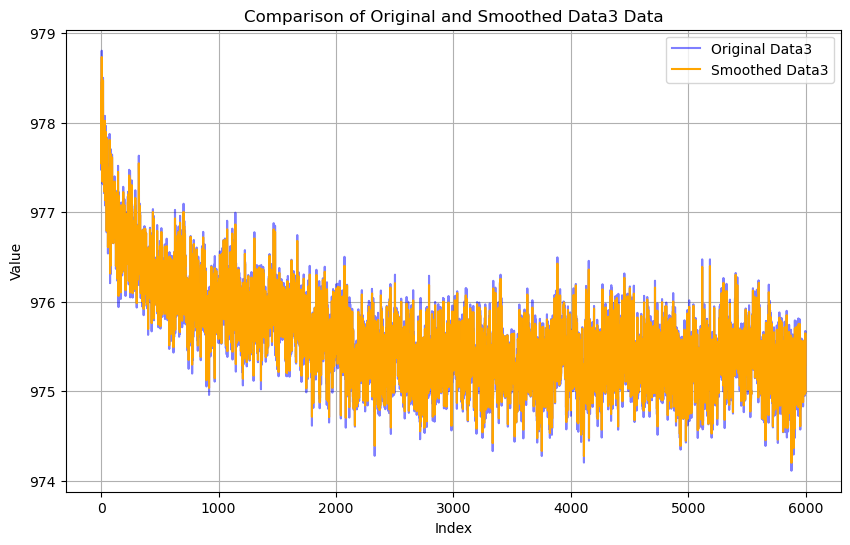

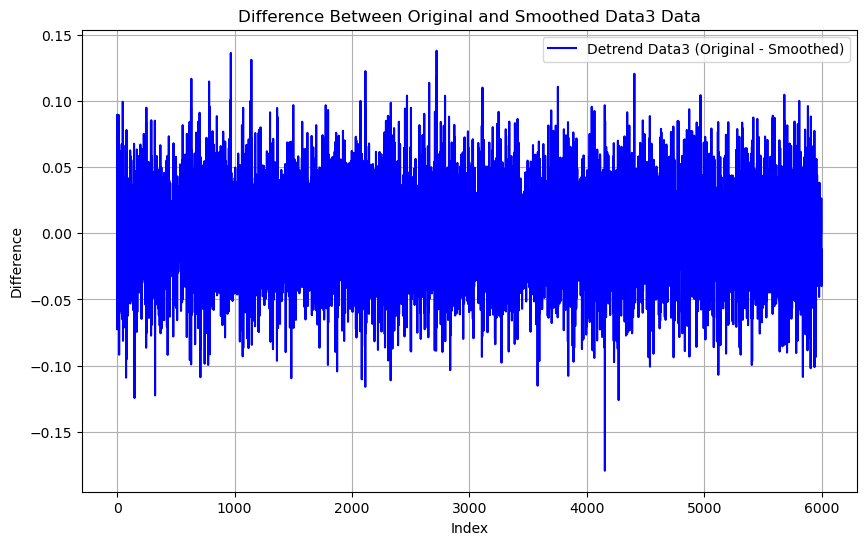

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

# Load excel file
datapath = 'Activation_trend.xlsx'
data = pd.read_excel(datapath)

def exponential_smoothing(data, alpha=0.9):
    smoothed_data = data.copy()
    smoothed_data[0] = data[0]  # First value remains the same
    
    # Apply exponential smoothing
    for i in range(1, len(data)):
        smoothed_data[i] = alpha * data[i] + (1 - alpha) * smoothed_data[i - 1]
    
    return smoothed_data

# Process each data column
for column in ['Data1', 'Data2', 'Data3']:
    # Apply exponential smoothing to the original data
    smoothed_data = exponential_smoothing(data[column].values)
    detrend_data = data[column].values - smoothed_data  # Compute the difference (detrend)
    
    # Create a plot to compare original and smoothed data
    plt.figure(figsize=(10, 6))
    plt.plot(data[column], label=f'Original {column}', color='blue', alpha=0.5)
    plt.plot(smoothed_data, label=f'Smoothed {column}', color='orange')
    plt.title(f'Comparison of Original and Smoothed {column} Data')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Create a plot to show the difference between original and smoothed data
    plt.figure(figsize=(10, 6))
    plt.plot(detrend_data, label=f'Detrend {column} (Original - Smoothed)', color='blue')
    plt.title(f'Difference Between Original and Smoothed {column} Data')
    plt.xlabel('Index')
    plt.ylabel('Difference')
    plt.legend()
    plt.grid(True)
    plt.show()


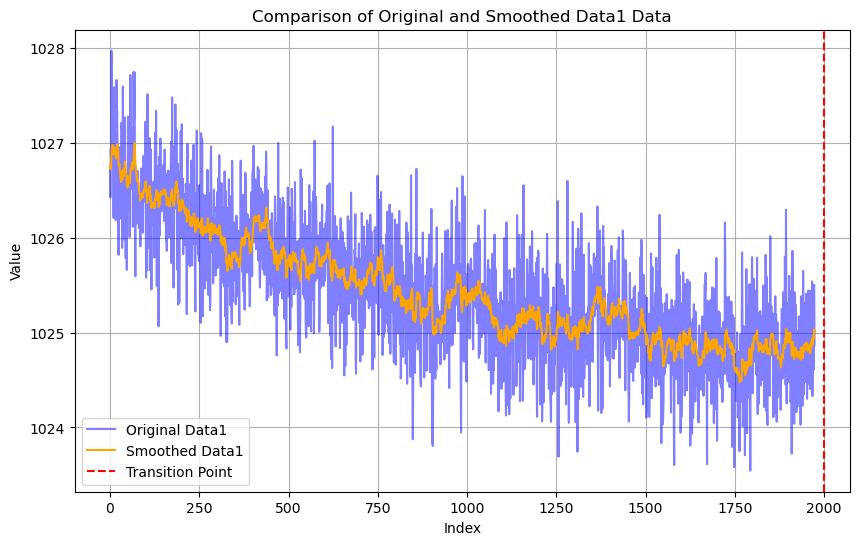

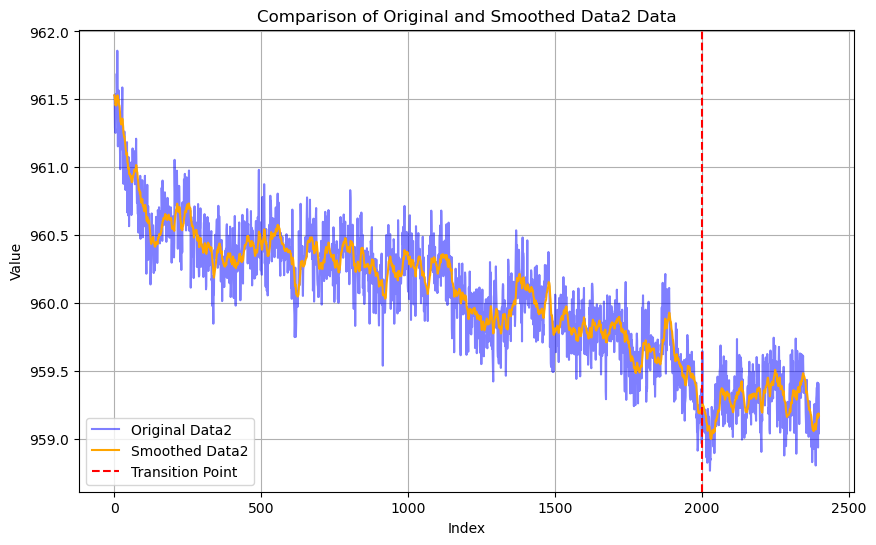

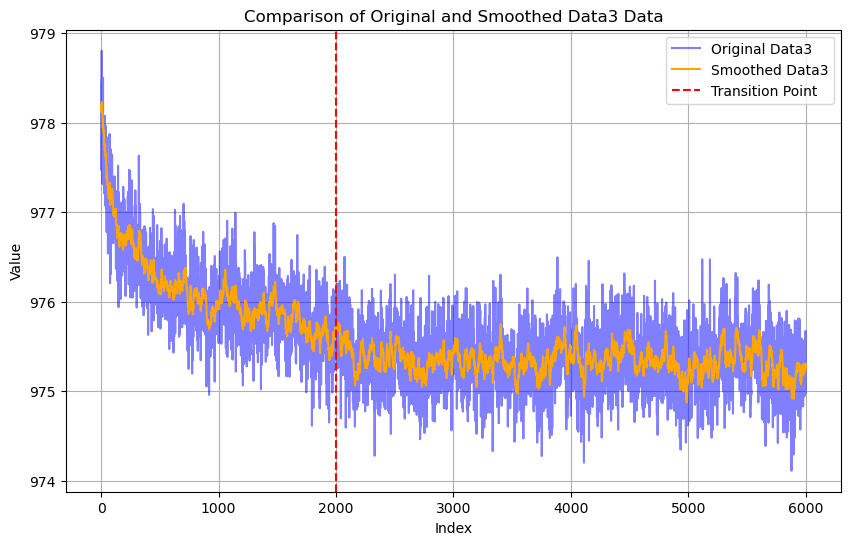

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# Load excel file
datapath = 'Activation_trend.xlsx'
data = pd.read_excel(datapath)

def exponential_smoothing(data, alpha=0.1):
    smoothed_data = data.copy()
    smoothed_data[0] = data[0]  # First value remains the same
    
    # Apply exponential smoothing
    for i in range(1, len(data)):
        smoothed_data[i] = alpha * data[i] + (1 - alpha) * smoothed_data[i - 1]
    
    return smoothed_data

# Process each data column
for column in ['Data1', 'Data2', 'Data3']:
    # Apply exponential smoothing to the original data
    smoothed_data = exponential_smoothing(data[column].values)
    detrend_data = data[column].values - smoothed_data

    
    # Create a plot to compare original and smoothed data
    plt.figure(figsize=(10, 6))
    plt.plot(data[column], label=f'Original {column}', color='blue', alpha=0.5)
    plt.plot(smoothed_data, label=f'Smoothed {column}', color='orange')
    # plt.plot(detrend_data, label=f'Detrend', color = 'red')
    plt.title(f'Comparison of Original and Smoothed {column} Data')
    plt.xlabel('Index')
    plt.ylabel('Value')
    # plt.axvline(x=2000, color='red', linestyle='--', label='Transition Point')  # Optional: highlight transition point
    plt.legend()
    plt.grid(True)
    plt.show()


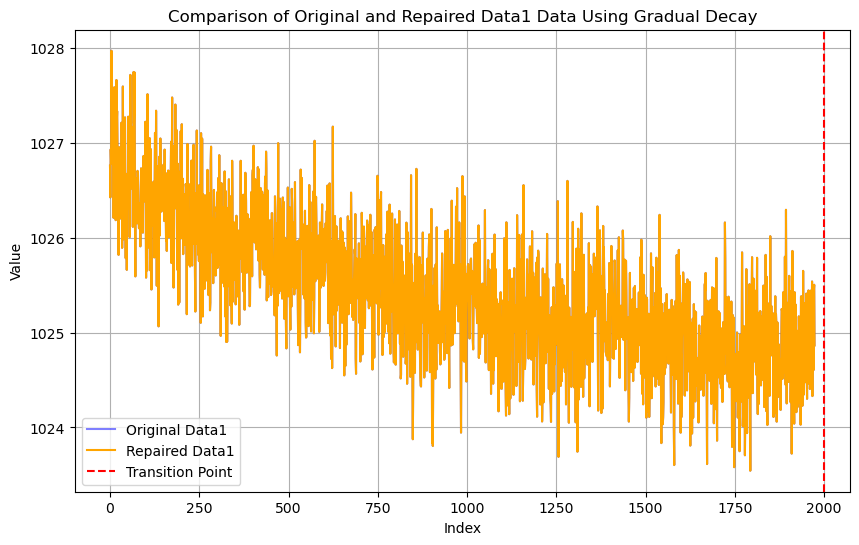

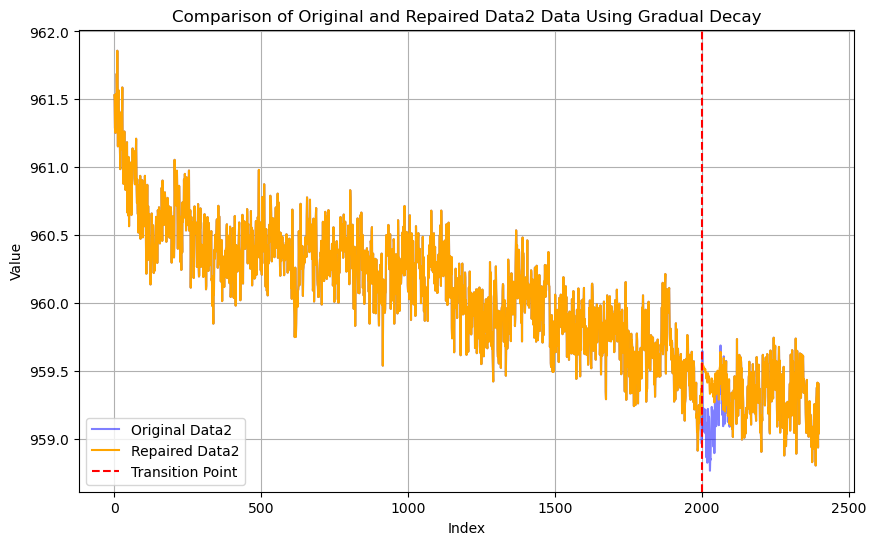

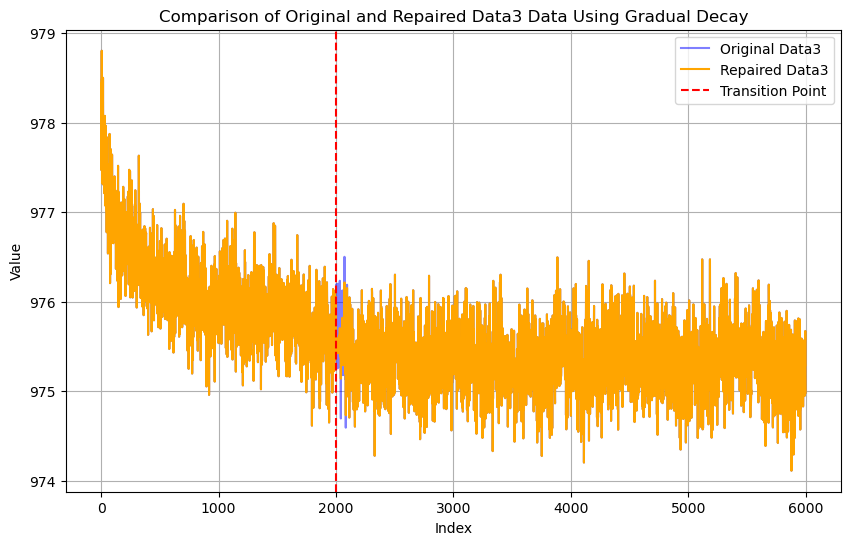

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load excel file
datapath = 'Activation_trend.xlsx'
data = pd.read_excel(datapath)

def gradual_decay_repair(data, repair_length=2000, transition_length=100):
    # Create a copy of the data to repair
    repaired_data = data.copy()
    
    # Identify the repair and transition regions
    repair_region = repaired_data[:repair_length]
    transition_region = repaired_data[repair_length:repair_length + transition_length]

    # Apply a polynomial fit or other smoothing method to the repair region
    # For simplicity, using a linear fit here
    x_repair = np.arange(len(repair_region))
    coeffs = np.polyfit(x_repair, repair_region, 1)  # Linear fit
    smoothed_repair = np.polyval(coeffs, x_repair)

    # Create the weight vector for gradual decay
    weights = np.linspace(1, 0, transition_length)

    # Smoothly transition from the repaired data to the original data
    for i in range(transition_length):
        repaired_data[repair_length + i] = (weights[i] * smoothed_repair[-1] + 
                                             (1 - weights[i]) * transition_region[i])

    return repaired_data

# Apply the gradual decay repair to each data column
for column in ['Data1', 'Data2', 'Data3']:
    repaired_data = gradual_decay_repair(data[column].values)
    
    # Create a plot to compare original and repaired data
    plt.figure(figsize=(10, 6))
    plt.plot(data[column], label=f'Original {column}', color='blue', alpha=0.5)
    plt.plot(repaired_data, label=f'Repaired {column}', color='orange')
    plt.title(f'Comparison of Original and Repaired {column} Data Using Gradual Decay')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.axvline(x=2000, color='red', linestyle='--', label='Transition Point')  # Highlight transition point
    plt.legend()
    plt.grid(True)
    plt.show()
